In [ ]:
# Importações necessárias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from google.colab import files

In [ ]:
# Abre a janela para você escolher o arquivo do seu PC
uploaded = files.upload()

Saving pacientes_diabetes_10.xlsx to pacientes_diabetes_10 (2).xlsx


In [ ]:
# Pega automaticamente o nome do arquivo que fizemos upload
nome_arquivo = list(uploaded.keys())[0]

df = pd.read_excel(nome_arquivo)

# Exibe a tabela
df

,Paciente_ID,Gestacoes,Glicose_mg_dL,Pressao_mmHg,Insulina_uU_mL,IMC,Historico_Familiar,Idade,Outcome
0,1,2,168,72,145,33.6,0.63,42,1
1,2,5,154,78,180,35.2,0.81,51,1
2,3,1,142,70,125,31.4,0.47,36,1
3,4,7,176,84,210,38.1,1.02,55,1
4,5,3,160,76,165,34.7,0.72,47,1
5,6,4,149,82,155,36.3,0.58,44,1
6,7,1,92,66,80,24.8,0.21,25,0
7,8,0,105,68,90,27.1,0.29,29,0
8,9,2,112,72,98,28.6,0.34,33,0
9,10,1,99,64,75,25.9,0.18,27,0


In [ ]:
# Definindo o que queremos prever e as características exatas da sua planilha
target = 'Outcome'
features = [
    'Gestacoes',
    'Glicose_mg_dL',
    'Pressao_mmHg',
    'Insulina_uU_mL',
    'IMC',
    'Historico_Familiar',
    'Idade'
]

X = df[features]
y = df[target]

In [ ]:
# Cria a árvore de decisão (já com o limite de profundidade 3)
model = tree.DecisionTreeClassifier(max_depth=3, random_state=42)

# Treina o modelo
model.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# Testando com os dados de um paciente fictício
# [Gestações, Glicose, Pressão, Insulina, IMC, Histórico Familiar, Idade]
paciente_teste = [[2, 110, 70, 80, 25.5, 0.4, 30]]

diagnostico = model.predict(paciente_teste)
print("Diagnóstico previsto (0 = Sem Diabetes, 1 = Com Diabetes):", diagnostico)

Diagnóstico previsto (0 = Sem Diabetes, 1 = Com Diabetes): [0]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


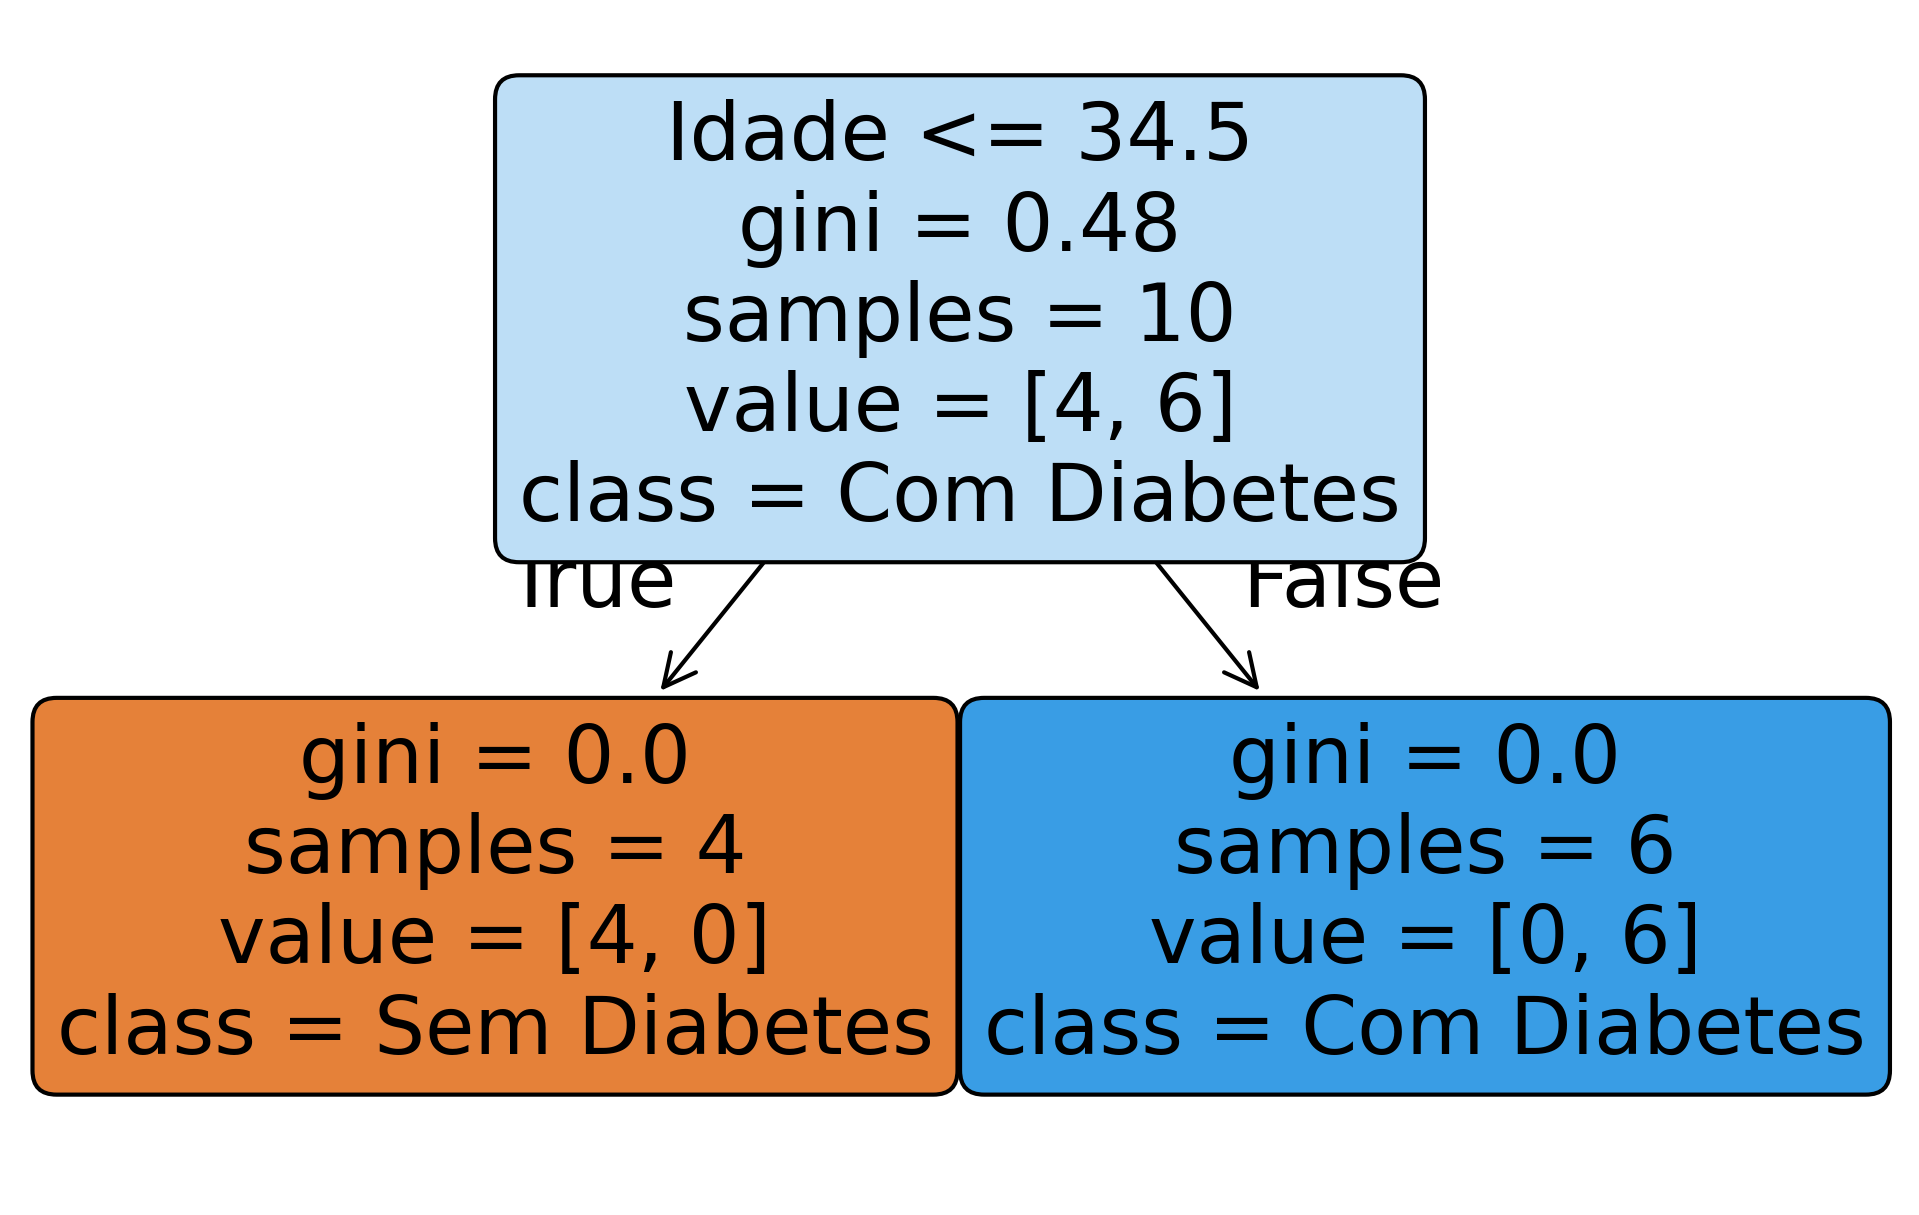

In [ ]:
# Configura o tamanho e a qualidade da imagem
plt.figure(figsize=(8, 5), dpi=300)

# Desenha a árvore
tree.plot_tree(model,
               feature_names=features,
               class_names=['Sem Diabetes', 'Com Diabetes'],
               filled=True,
               rounded=True)

# Exibe o gráfico
plt.show()